<a href="https://colab.research.google.com/github/Subroy1/MSAI_AllPracticeModules/blob/main/prompt_III_Assignment17_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data
To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

**The dataset relates to a total of 17 marketing campaigns coducted from 2008-May to November 2010  during which 79,354 contacts were made by the bank agents , mainly as phone contacts . The offers were about opening long-term fixed deposits with attractive interest rates.**

The dataset however filtered to around 41188 contacts.

During data understanding , we would look into-
1. Understanding missing and incorrect values

2. Figuring out the target variable and its relationship with individual features.

3. Do feature engineering

4. Class Imbalance to avoid model learning from overrepresented class .

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (accuracy_score, recall_score,f1_score,RocCurveDisplay,
PrecisionRecallDisplay, precision_score, precision_recall_curve, classification_report, ConfusionMatrixDisplay, confusion_matrix)

In [7]:
df = pd.read_csv("https://raw.githubusercontent.com/Subroy1/MSAI_AllPracticeModules/refs/heads/main/Module%2017/data/bank-additional-full.csv?token=GHSAT0AAAAAADRZHKQ5FVTLBRS6IEDVZ25K2PFKPYQ", sep = ';')

In [14]:
df.head(2)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


The dataset contains the target variable y which seems to be the result of the campaign represented by a boolean yes / no

In [11]:
# Print the percentage
pd.DataFrame(df['y'].value_counts(normalize=True))
# There is class imbalance, we will use SMOTE or class weights on training data before model building.

,proportion
y,
no,0.887346
yes,0.112654


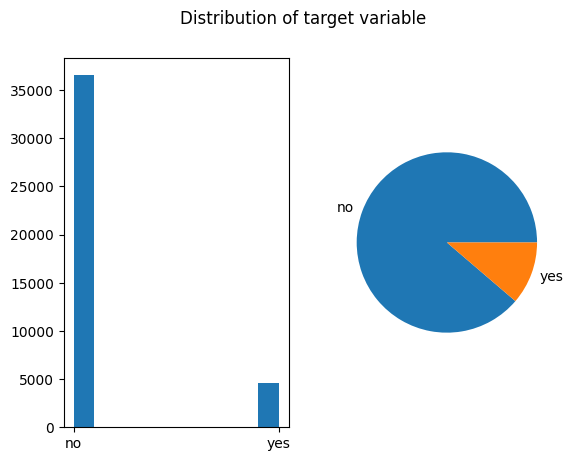

In [17]:
# Plot histogram of target variable y and also the pie chart
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('Distribution of target variable')
ax1.hist(df['Response'])
ax2.pie(df['Response'].value_counts(), labels = df['Response'].unique())
plt.show()


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

#Data Cleaning

In [28]:
# Find duplicates and null values
df.isnull().sum()# Gives no null elements
df.duplicated().sum()# Gives 12 duplicate elements , can be cleaned up
df=df[~df.duplicated()]
df.shape


(41176, 21)

In [ ]:
#display all numerical columns
df[df.select_dtypes(include='number').columns].head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0


In [18]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

**Business Understanding**

The goal is to increase efficiency of directed campaigns for long-term deposit
subscriptions, hence prioritizing resources to probable subscribers  in an efficient manner by reducing the number of contacts.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

# Feature Engineering

- Feature engineering is the process of transforming raw data into features or variables that a Machine Learning model can effectively use to make predictions.

- These features are the values the model uses as inputs, so creating high-quality features can significantly improve the model's performance.

  - For **categorical features**, it is **mandatory** to transform them before using them in the model. This is because Machine Learning models cannot work directly with text or categories, so they need to be converted into a numerical format (e.g., one-hot encoding or ordinal encoding).

  - For **numerical features**, transformation is not mandatory, but it is recommended. Normalizing or standardizing numerical features can improve the model's accuracy and stability, especially when variables have very different magnitudes of values.

  - **Handling missing values**: Missing values can disrupt model performance. Depending on the data, you may need to impute missing values using methods like mean, median, mode, or interpolation. Alternatively, you can drop rows or columns with missing data if appropriate.

  - **Creating interaction features**: Sometimes, the interaction between two or more features can provide additional predictive power. For example, multiplying or combining features can reveal hidden relationships.

  - **Binning or discretizing features**: For continuous variables, you can create bins or categories (e.g., age groups) to simplify relationships and improve interpretability.

  - **Feature selection**: Removing irrelevant or redundant features can enhance model performance by reducing noise and overfitting.

  - **Dimensionality reduction**: Techniques like Principal Component Analysis (PCA) or Feature Agglomeration can help reduce the number of features while retaining essential information.

  - **Custom feature creation**: Sometimes, domain knowledge can guide you to create new features that better represent the problem at hand. Examples include:
    - Combining date-related features to create a "time of day" or "day of the week" variable.
    - Creating ratios or percentages (e.g., `Fare/FamilySize` to represent how much was paid per person).
    - Encoding geographic features such as latitude/longitude into clusters or distances from specific locations.
    - Generating text-based features, like word counts, sentiment scores, or keyword flags in textual data.
    - Building flags or binary indicators (e.g., "IsSeniorCitizen" for passengers over 60 years old).

  - **Applying domain-specific transformations**: Use domain expertise to create highly specific features that are unique to your dataset or industry (e.g., engineering features based on physical formulas in scientific data, or customer segmentation in marketing data).


In [ ]:
# Normalize common yes/no targets to 1/0 if needed
if y.dtype == "object":
    y_lower = y.astype(str).str.lower().str.strip()
    if set(y_lower.unique()) <= {"yes", "no"}:
        y = (y_lower == "yes").astype(int)

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

# ⚠️ Split Data into Training (Train) and Testing (Test) ⚠️

It is **crucial** to split the data into training and testing sets **BEFORE** performing any feature engineering or training the model.

If you transform the data before splitting, you may inadvertently allow information from the test set to leak into the training data. This leads to overfitting, where the model appears to perform very well but does not truly reflect its performance on new or unseen data.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y if pd.Series(y).nunique() > 1 else None
)

# Balancing your dataset

In classification tasks, checking if your data is balanced is crucial because an imbalanced dataset can cause the model to focus on predicting the majority class while ignoring the minority class, leading to biased and poor performance, especially for the underrepresented class. Balancing the data ensures that the model learns equally from all classes, improving its ability to generalize and accurately predict the minority class, which is often critical in applications like fraud detection, medical diagnoses, or churn prediction.

### How to balance your data?
1.  **Resampling Methods**
- Oversampling: Increase the number of samples in the minority class (e.g., using SMOTE, ADASYN, or simple duplication).
- Undersampling: Reduce the number of samples in the majority class to match the minority class.

2. **Class Weights**
Many algorithms (e.g., logistic regression, random forest, SVM) allow you to assign higher weights to the minority class, so the model pays more attention to it.


### Key considerations

- Always balance only the **training** set, not the test set.
- Compare model performance with and without balancing.
- Choose the balancing method carefully, as oversampling can lead to overfitting, and undersampling may lose important information.


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [ ]:
# Build a dummy classifier

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

For DT and SVM, the rminer got out of
memory or the processing did not end despite waiting
several hours. Simplification (e.g. better data selection)
was needed if knowledge was to be extracted successfully.

### Problem 9: Score the Model

What is the accuracy of your model?

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

1.Predictive metrics for all the DM algorithms and CRISP-DM iterations - Plot the table for all clasifiers  

2. Plot the ROC AUC and Lift curves for finding the top deciles for making the campaigns focus on customers most likely to respond to marketing cammpaighns.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

##### Questions